# 0. Imports

In [42]:
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, cross_val_score, GridSearchCV, StratifiedKFold, HalvingGridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report,make_scorer, balanced_accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.experimental import enable_halving_search_cv

proj = ccrs.PlateCarree()

# 1. Data

In [69]:
DATA_DIR = "../data/"

LAT_LON = ["Lat", "Lon"]

RANDOM_STATE = 11

In [3]:
#LPJ-GUESS output
lpj_df = pl.read_csv(DATA_DIR + "LPJ-GUESS_output_BERN1.csv")
lpj_df = lpj_df.rename({col: col + f"_lpj" for col in lpj_df.columns if not col in LAT_LON})
lpj_df

Lon,Lat,NPP_lpj,SoilR_lpj,MaxBiomeCmax_lpj,MaxBiomeLAI_lpj,VegC_lpj,LitterC_lpj,SoilC_lpj,Biome_Cmax_lpj,Biome_LAI_lpj,Biome_obs_lpj
f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
39.75,-1.25,0.429,0.39,0.449,1.9821,1.225,0.758,5.941,8,12,12
150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
-63.75,82.75,0.0,0.0,0.0,0.0,0.0,0.003,0.002,13,13,17
59.25,30.75,0.043,0.042,0.09,0.2146,0.127,0.084,0.543,7,11,14
24.25,27.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13,13,17
…,…,…,…,…,…,…,…,…,…,…,…
114.75,34.75,0.35,0.307,3.389,2.5025,3.502,1.763,3.537,5,5,5
12.25,52.25,0.507,0.425,6.303,3.3822,6.785,4.612,12.687,5,5,5
-154.25,61.75,0.013,0.01,0.014,0.0951,0.014,0.097,1.207,11,11,17


In [4]:
# Grid information
grid_df = pl.read_csv(DATA_DIR + "gridlist_pan_gfed_ISO3_UN_ecoregion.txt", separator=' ')
grid_df = grid_df.rename({col: col + f"_grid" for col in grid_df.columns if not col in LAT_LON})
grid_df

Lon,Lat,GFED-region_grid,Pan_2007_grid,ISO3_grid,UN_grid,Ecoregion_grid
f64,f64,i64,str,str,i64,i64
-69.75,-55.25,5,"""Americas""","""CHL""",152,4
-69.25,-55.25,5,"""Americas""","""CHL""",152,4
-71.25,-54.75,5,"""Americas""","""CHL""",152,4
-70.75,-54.75,5,"""Americas""","""CHL""",152,4
-70.25,-54.75,5,"""Americas""","""CHL""",152,4
…,…,…,…,…,…,…
-73.75,79.75,1,"""Canada""","""CAN""",124,11
-73.25,79.75,1,"""Canada""","""CAN""",124,11
-72.75,79.75,1,"""Canada""","""CAN""",124,11


In [5]:
# Soil texture
soil_df = pl.read_csv(DATA_DIR + "soilmap.dat", separator="\t")
soil_df = soil_df.drop_nans().rename({"lon": "Lon", "lat": "Lat"})
soil_df = soil_df.rename({col: col + f"_soil" for col in soil_df.columns if not col in LAT_LON})
soil_df

Lon,Lat,clay_soil,silt_soil,sand_soil,orgC_soil,CN_soil,pH_soil,cellfraction_soil
f64,f64,f64,f64,f64,f64,f64,f64,f64
-179.75,71.25,0.08,0.37,0.55,0.02,11.0,5.9,0.482
-179.75,68.75,0.2,0.48,0.32,0.031,17.0,6.3,0.753
-179.75,68.25,0.2,0.48,0.32,0.031,17.0,6.3,0.447
-179.75,67.75,0.2,0.48,0.32,0.031,17.0,6.3,0.526
-179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.422
…,…,…,…,…,…,…,…,…
179.75,67.25,0.2,0.48,0.32,0.031,17.0,6.3,0.455
179.75,66.75,0.2,0.48,0.32,0.031,17.0,6.3,0.408
179.75,66.25,0.2,0.48,0.32,0.031,17.0,6.3,0.597


In [6]:
# Load all climate datafiles and put in one dictionary
climate_files = {
    "tswrf": "Tswrfdaymean1961_1990.csv",
    "pre": "Predaymean1961_1990.csv",
    "tmp": "Tmpdaymean1961_1990.csv",
    "tmax": "Tmaxdaymean1961_1990.csv",
    "tmin": "Tmindaymean1961_1990.csv"
}

climate_df = {}
for name, path in climate_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    climate_df[name] = df

# Load all climate statistics datafiles and put in one dictionary
stats_files = {
    "tswrf": "Tswrfdaymean1961_1990_stats.csv",
    "pre": "Predaymean1961_1990_stats.csv",
    "tmp": "Tmpdaymean1961_1990_stats.csv",
    "tmax": "Tmaxdaymean1961_1990_stats.csv",
    "tmin": "Tmindaymean1961_1990_stats.csv"}

stats_df = {}
for name, path in stats_files.items():
    df = pl.read_csv(DATA_DIR + path)
    df = df.rename({col: col + f"_{name}" for col in df.columns if not col in LAT_LON})
    stats_df[name] = df

## 1.1 Merge dataframes

In [7]:
# Merge all dataframes on Lat and Lon
merged_df = lpj_df.join(grid_df, on=LAT_LON, how="inner").join(soil_df, on=LAT_LON, how="inner")

for name, df in stats_df.items():
    merged_df = merged_df.join(df, on=LAT_LON, how="inner")

In [8]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open(DATA_DIR + "legend of biomes.txt", 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [ ]:
def drop_ground_truth(df):
    """Drops Lat, Lon, and all columns that end with '_lpj' or '_grid' from the dataframe."""
    return df.select([col for col in df.columns if not col.endswith(("_lpj", "_grid")) and col not in ["Lat", "Lon"]])

def drop_columns(df, str_in_columns_to_drop, keep_columns=[]):
    """Drops columns containing a specified string, except specified columns."""
    # Drop columns containing the specified string, except for those in keep_columns
    return df.select([col for col in df.columns if str_in_columns_to_drop not in col or col in keep_columns])    

# Multiclass classification

#### Data split
Split your dataset into two parts: a training set, and a test set. The training set is used to
train the model, the validation set to tune hyperparameters, and the test set to evaluate
model performance.

In [ ]:
# Make new df with only european countries
europe_df = merged_df.filter(pl.col("GFED-region_grid") == 6) 
russia_df = merged_df.filter(pl.col("ISO3_grid") == "RUS")

# Prepare X and y for the europe_df
X = drop_ground_truth(europe_df)
y = europe_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32)).to_numpy().flatten()

# Prepare X and y for the russia_df
X_russia = drop_ground_truth(russia_df)
y_russia = russia_df.select(pl.col("Biome_obs_lpj").cast(pl.Int32)).to_numpy().flatten()

## Model 1: All features included
Use cross-validation to tune hyperparameters like the number of trees, tree depth, and
minimum leaf samples. This step can help improve model performance. If you encounter
issues with runtime, consider narrowing your focus to fewer geographic regions. It is also
possible to sample the grid list with the .sample() function on Pandas DataFrames, in that
case, make sure to sample only the training dataset and not the full dataset.

In [20]:
# Define parameters to test in the grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Run grid search to find the best hyperparameters
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X, y)

multi_class = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV accuracy: 0.8463


### Model Evaluation
Evaluate the model's performance using appropriate metrics for multiclass classification.



In [21]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0),
    "cohen_kappa": make_scorer(cohen_kappa_score)
}

cv_results = cross_validate(multi_class, X, y, cv=cv, scoring=scoring, n_jobs=-1)

metrics_cv = pd.DataFrame({
    "metric": ["Accuracy", "Balanced accuracy", "Macro F1", "Cohen's kappa"],
    "mean": [cv_results[f"test_{m}"].mean() for m in scoring],
    "std": [cv_results[f"test_{m}"].std() for m in scoring]
})

display(metrics_cv.round(4))


/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,metric,mean,std
0,Accuracy,0.8463,0.0071
1,Balanced accuracy,0.5498,0.0350
2,Macro F1,0.5608,0.0394
3,Cohen's kappa,0.7850,0.0094


### Feature importance and selection
Analyze which features played the most crucial role in your model's decisions. What happens when you are limiting the number of features? Also, are there any auto-correlations
in the feature data?

In [25]:
# Print feature importances for the tuned multi-class model
feature_imp = pd.DataFrame(
    {'importance':multi_class.feature_importances_},
    index=X.columns)
feature_imp = feature_imp.sort_values(by='importance', ascending=False) 

print("\nFeature Importances (multi-class model):")
print(feature_imp.head(60))


Feature Importances (multi-class model):
                    importance
SummerMean_tmp        0.057324
SummerMedian_tmp      0.057292
SummerMedian_tmin     0.046639
SummerMean_tmin       0.042036
FallMean_tmp          0.041043
FallMedian_tmp        0.039750
WinterMedian_tmp      0.033807
SummerMean_tmax       0.032672
FallMean_tmin         0.031543
FallMedian_tmax       0.029720
WinterMean_tmp        0.028494
FallMedian_tmin       0.024659
SummerMedian_tmax     0.022542
WinterMean_tmax       0.022113
FallMean_tmax         0.020729
SpringMedian_tmp      0.020687
SpringMean_tmp        0.020683
WinterMedian_tmax     0.020153
SpringMean_tswrf      0.018463
SpringMedian_tmax     0.018030
WinterMean_tswrf      0.017545
WinterMedian_tmin     0.017483
SpringMean_tmax       0.017163
FallMean_pre          0.015126
WinterMedian_tswrf    0.014690
FallMedian_pre        0.014583
WinterMean_tmin       0.013277
SummerMean_pre        0.012517
SpringMedian_tswrf    0.011580
SummerMedian_pre      0.0108

In [ ]:
# Print importance of soil features
[f for f in X.columns if "soil" in f] 
feature_importance = pd.Series(multi_class.feature_importances_, index=X.columns)
print(feature_importance[feature_importance.index.str.contains("soil")].sort_values(ascending=False))

cellfraction_soil    0.005143
pH_soil              0.003586
sand_soil            0.002845
orgC_soil            0.002789
silt_soil            0.002617
clay_soil            0.002570
CN_soil              0.002115
dtype: float64


## Model 2: No medians or soil features

In [26]:
# Remove median and soil features
X_red = drop_columns(X, "Median")
X_red = drop_columns(X_red, "soil")

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features: {X_red.shape[1]}")

# Tune a new Random Forest using the same European cross-validation
grid_search_red = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_search_red.fit(X_red, y)

# Get the best model fitted on all European data
multi_class2 = grid_search_red.best_estimator_

print("\nBest parameters (reduced features):", grid_search_red.best_params_)
print(f"Best European CV accuracy (reduced features): {grid_search_red.best_score_:.4f}")

Original number of features: 67
Reduced number of features: 40
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Best parameters (reduced features): {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}
Best European CV accuracy (reduced features): 0.8449


In [ ]:
feature_imp2 = pd.DataFrame({"feature": X_red.columns, "importance": multi_class2.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
print(f"Number of features: {len(feature_imp2)}")
display(feature_imp2)

Number of features: 40


,feature,importance
0,SummerMean_tmp,0.096143
1,FallMean_tmp,0.085247
2,FallMean_tmin,0.071973
3,SummerMean_tmax,0.070532
4,SummerMean_tmin,0.068971
5,WinterMean_tmax,0.059350
6,WinterMean_tmp,0.056292
7,WinterMean_tswrf,0.044800
8,SpringMean_tswrf,0.040028
9,SpringMean_tmp,0.036955


## Model 3: No Std features

In [ ]:
# Remove features containing "Std" from the reduced feature set
X_red_std = drop_columns(X_red, "Std")

print(f"Features before removing Std: {X_red.shape[1]}")
print(f"Features after removing Std: {X_red_std.shape[1]}")
print("Removed features:", [col for col in X_red.columns if "Std" in col])

# Tune a Random Forest using European cross-validation (hyper parameter tuning)
grid_search_std = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search_std.fit(X_red_std, y)
multi_class3 = grid_search_std.best_estimator_ # using the most optimal hyper parameters

print("\nBest parameters:", grid_search_std.best_params_)
print(f"Best European CV accuracy (without Median, soil, or Std features): {grid_search_std.best_score_:.4f}")


Features before removing Std: 40
Features after removing Std: 20
Removed features: ['SpringStd_tswrf', 'SummerStd_tswrf', 'FallStd_tswrf', 'WinterStd_tswrf', 'SpringStd_pre', 'SummerStd_pre', 'FallStd_pre', 'WinterStd_pre', 'SpringStd_tmp', 'SummerStd_tmp', 'FallStd_tmp', 'WinterStd_tmp', 'SpringStd_tmax', 'SummerStd_tmax', 'FallStd_tmax', 'WinterStd_tmax', 'SpringStd_tmin', 'SummerStd_tmin', 'FallStd_tmin', 'WinterStd_tmin']
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Best European CV accuracy (without Median, soil, or Std features): 0.8466


In [37]:
feature_imp3 = pd.DataFrame({"feature": X_red_std.columns, "importance": multi_class3.feature_importances_}).sort_values("importance", ascending=False).reset_index(drop=True)
print(f"Number of features: {len(feature_imp3)}")
display(feature_imp3)

Number of features: 20


,feature,importance
0,SummerMean_tmp,0.130697
1,FallMean_tmp,0.103939
2,WinterMean_tmp,0.076378
3,SummerMean_tmin,0.073729
4,FallMean_tmin,0.072499
5,SummerMean_tmax,0.062783
6,SpringMean_tswrf,0.052567
7,WinterMean_tmax,0.050960
8,FallMean_tmax,0.048891
9,WinterMean_tswrf,0.045002


## Compare performance of the different models with more or less features

In [34]:
# Compare the model performance with more or less features
print(f"All features:                         {grid_search.best_score_:.4f}")
print(f"Without Median and soil:              {grid_search_red.best_score_:.4f}")
print(f"Without Median, soil, and Std:        {grid_search_std.best_score_:.4f}")


All features:                         0.8463
Without Median and soil:              0.8449
Without Median, soil, and Std:        0.8466


### Evaluate the final model (model 3)

OBS: This evaluation and the one above is not done on a test set in europe. It is done using kfold cross validation as was used in the training and hyper parameter tuning of the model.

In [40]:
# Classification report for the model without Median, soil, and Std features

y_pred_cv = cross_val_predict(multi_class3, X_red_std, y, cv=cv, n_jobs=-1)
labels = multi_class3.classes_
names = [biome_names[i-1] for i in labels]

print(classification_report(y, y_pred_cv, labels=labels, target_names=names, zero_division=0))

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


                      precision    recall  f1-score   support

  Boreal ever forest       0.93      0.96      0.94       645
 Temp/boreal mix fo.       0.72      0.47      0.57       370
   Temp decid forest       0.83      0.94      0.88      1234
 Temp broad ever fo.       0.87      0.88      0.88       170
   Temp mixed forest       0.62      0.37      0.46        49
      Moist savannas       0.00      0.00      0.00         6
        Dry savannas       0.92      0.85      0.88       102
      Tall grassland       0.00      0.00      0.00         1
       Dry grassland       0.00      0.00      0.00         5
    Xeric wood/shrub       0.85      0.84      0.84       155
              Desert       0.50      0.10      0.17        10
Arctic/alpine tundra       0.71      0.66      0.68        70

            accuracy                           0.85      2817
           macro avg       0.58      0.51      0.53      2817
        weighted avg       0.83      0.85      0.83      2817



In [41]:
# Information about the model 
trees = multi_class3.estimators_

print(f"Number of trees: {len(trees)}")
print(f"Number of features: {multi_class3.n_features_in_}")
print(f"Number of classes: {len(multi_class3.classes_)}")
print(f"Total nodes: {sum(tree.tree_.node_count for tree in trees)}")
print(f"Total leaves: {sum(tree.tree_.n_leaves for tree in trees)}")
print(f"Average nodes per tree: {np.mean([tree.tree_.node_count for tree in trees]):.1f}")
print(f"Average leaves per tree: {np.mean([tree.tree_.n_leaves for tree in trees]):.1f}")
print(f"Maximum depth across trees: {max(tree.tree_.max_depth for tree in trees)}")

Number of trees: 200
Number of features: 20
Number of classes: 12
Total nodes: 63234
Total leaves: 31717
Average nodes per tree: 316.2
Average leaves per tree: 158.6
Maximum depth across trees: 10


## Test the model on Russia

In [53]:
# Remove unwanted features from X_bona
X_russia = drop_columns(X_russia, "Median")
X_russia = drop_columns(X_russia, "soil")
X_russia = drop_columns(X_russia, "Std")

# Predict using the model trained on Europe
y_russia_pred = multi_class3.predict(X_russia)

# Evaluate performance
print(f"Russia accuracy: {accuracy_score(y_russia, y_russia_pred):.4f}")
print(f"Russia balanced accuracy: {balanced_accuracy_score(y_russia, y_russia_pred):.4f}")
print(f"Russia macro F1: {f1_score(y_russia, y_russia_pred, average='macro', zero_division=0):.4f}")

# Classification report
labels = multi_class3.classes_
names = [biome_names[i-1] for i in labels]

print("\nClassification report — Russia:")
print(classification_report(y_russia, y_russia_pred, labels=labels, target_names=names, zero_division=0))


Russia accuracy: 0.4697
Russia balanced accuracy: 0.2794
Russia macro F1: 0.1991

Classification report — Russia:
                      precision    recall  f1-score   support

  Boreal ever forest       0.47      0.49      0.48      4552
 Temp/boreal mix fo.       0.02      0.36      0.05        50
   Temp decid forest       0.22      0.97      0.36       431
 Temp broad ever fo.       0.00      0.00      0.00         0
   Temp mixed forest       0.00      0.00      0.00         1
      Moist savannas       0.00      0.00      0.00         0
        Dry savannas       0.00      0.00      0.00        26
      Tall grassland       0.00      0.00      0.00       114
       Dry grassland       0.00      0.00      0.00        41
    Xeric wood/shrub       0.74      0.54      0.62       128
              Desert       1.00      0.00      0.00      1163
Arctic/alpine tundra       0.66      0.71      0.68      3886

           micro avg       0.47      0.53      0.50     10392
           macro

## Make plots
### Confusion matrix

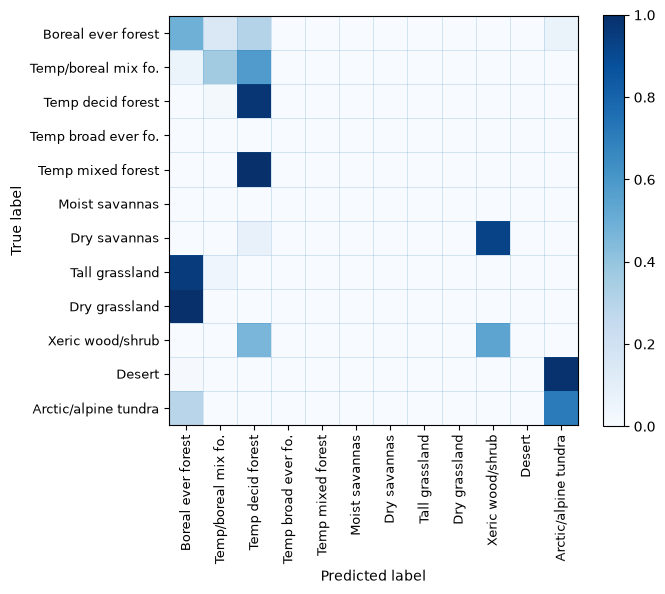

In [65]:
"""# Get the target names for the classes in the model
model_target_names = [biome_names[i - 1] for i in multi_class3.classes_]

# Make confusion matrix for the tuned multi-class model
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class3, X_red, y_test, display_labels=model_target_names, 
    cmap=plt.cm.Blues, normalize="true", include_values=False)
disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)
plt.xticks(rotation=90)
#disp.ax_.set_title("Confusion Matrix for Tuned Multi-Class Model (Europe)", fontsize=12)
plt.show()"""
"""
# Get target names for the classes learned by the model
model_target_names = [biome_names[i-1] for i in multi_class3.classes_]

# Make normalized confusion matrix for Boreal North America
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class3, X_russia, y_russia,
    display_labels=model_target_names,
    cmap=plt.cm.Blues, normalize="true", include_values=False
)
disp.ax_.tick_params(axis="both", labelsize=9)

for i in range(len(model_target_names) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)

plt.xticks(rotation=90)
plt.show()"""


# Classes learned by the model
labels = multi_class3.classes_
model_target_names = [biome_names[int(i) - 1] for i in labels]

fig, ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay.from_estimator(
    multi_class3, X_russia, y_russia,
    labels=labels, display_labels=model_target_names,
    cmap=plt.cm.Blues, normalize="true", include_values=False,
    ax=ax, im_kw={"vmin": 0, "vmax": 1}, colorbar=False
)

# Add a shorter color bar
fig.colorbar(disp.im_, ax=ax, shrink=0.73)

disp.ax_.tick_params(axis="both", labelsize=9)
for i in range(len(labels) + 1):
    disp.ax_.axvline(i - 0.5, linewidth=0.4, alpha=0.3)
    disp.ax_.axhline(i - 0.5, linewidth=0.4, alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Comment: Some of the diagonal boxes are very light. This indicates that the model has low recall for that biome, i.e. it was bad at predicting that biome correctly. Could depend on few observations for that biome or that it is hard to distinguish from other biomes. 

It seems like tall grassland is predicted as boreal ever forest or arctic tundra.

### Observed biomes Europe and Russia

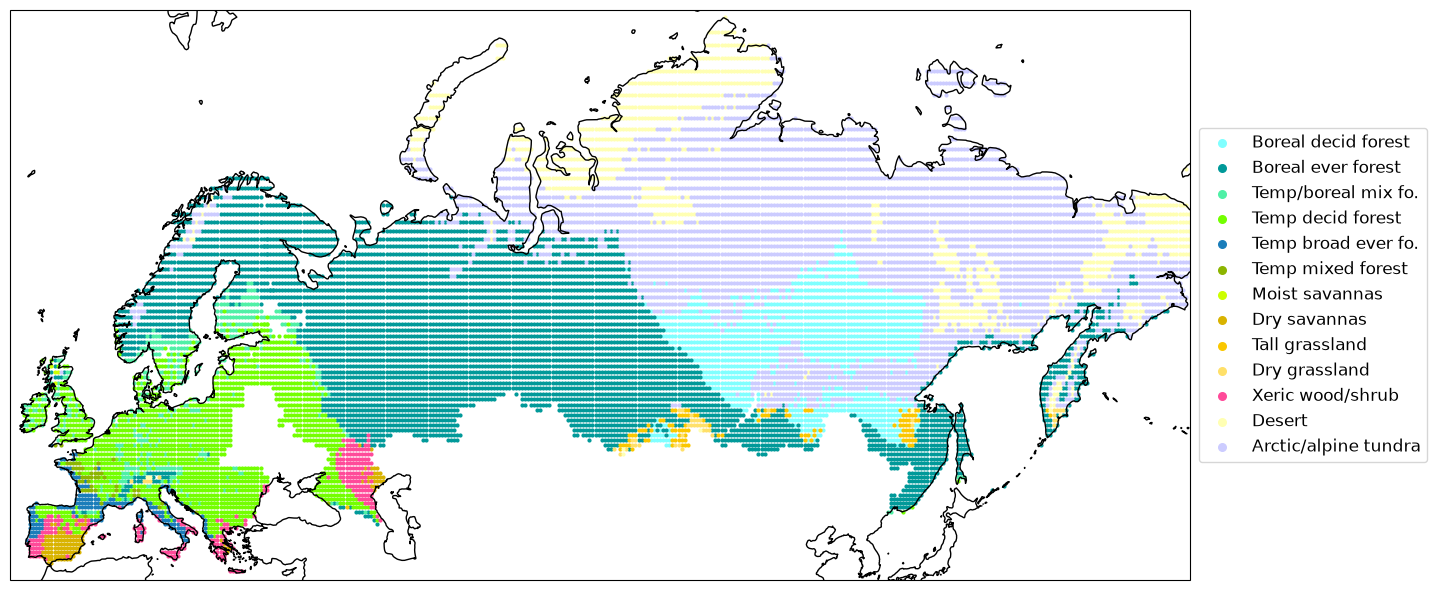

In [46]:
# make one df with both europe and russia data
europe_russia_df = pl.concat([europe_df, russia_df])

europe_russia_mean_lon = europe_russia_df.select(pl.col("Lon")).mean().item()
proj_europe = ccrs.Mercator(central_longitude=europe_russia_mean_lon)

# Biome IDs that are actually present in Europe and Russia
present_biomes = europe_russia_df.select("Biome_obs_lpj").unique().sort("Biome_obs_lpj").to_series().to_list()

fig, ax = plt.subplots(figsize=(18, 6), subplot_kw={"projection": proj_europe})

for biome_id in present_biomes:
    i = biome_id - 1
    name = biome_names[i]
    biome = europe_russia_df.filter(pl.col("Biome_obs_lpj") == biome_id)
    ax.scatter(biome["Lon"].to_numpy(),biome["Lat"].to_numpy(),color=biome_rgbs[i],s=4,label=name,transform=proj)

ax.set_extent([-12, 180, 34, 78], crs=ccrs.PlateCarree())
ax.coastlines()

legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)
for handle in legend.legend_handles:
    handle.set_sizes([30])

#plt.title("Biome distribution in Europe and Russia (observed biomes)", fontsize=16)
plt.tight_layout()
plt.show()

### Predicted biomes in Russia

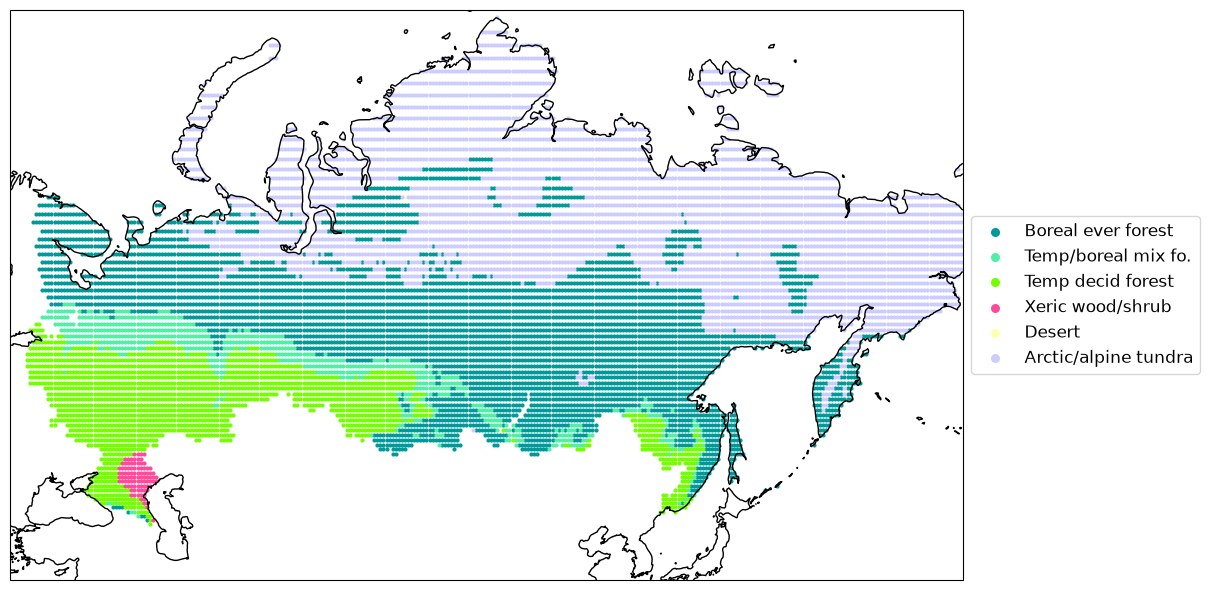

In [130]:
# Predict biomes in Russia
X_russia_model = russia_df.select(X_red_std.columns).to_pandas()
russia_pred = multi_class3.predict(X_russia_model)

# Add predictions to the Russia dataframe
russia_pred_df = russia_df.with_columns(pl.Series("Biome_pred", russia_pred))

# Biome IDs predicted in Russia
present_biomes = sorted(set(russia_pred.tolist()))

# Map projection
russia_mean_lon = russia_df.select(pl.col("Lon")).mean().item()
proj_russia = ccrs.Mercator(central_longitude=russia_mean_lon)

fig, ax = plt.subplots(figsize=(18, 6), subplot_kw={"projection": proj_russia})

for biome_id in present_biomes:
    i = int(biome_id) - 1
    name = biome_names[i]
    biome = russia_pred_df.filter(pl.col("Biome_pred") == biome_id)
    ax.scatter(biome["Lon"].to_numpy(), biome["Lat"].to_numpy(),
               color=biome_rgbs[i], s=4, label=name, transform=ccrs.PlateCarree())

ax.set_extent([25, 180, 34, 78], crs=ccrs.PlateCarree())
ax.coastlines()

legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12) 
for handle in legend.legend_handles:
    handle.set_sizes([30])

# plt.title("Predicted biome distribution in Russia", fontsize=16)
plt.tight_layout()
plt.show()

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


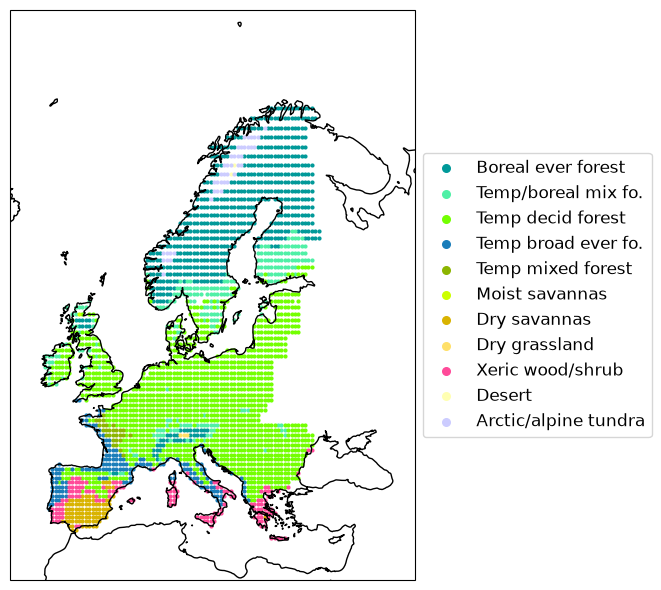

In [ ]:
# Features and out-of-fold predictions for Europe
X_europe = europe_df.select(X_red_std.columns).to_pandas()
oof_pred = cross_val_predict(multi_class3, X, y, cv=cv, n_jobs=-1)

# Add predictions to the dataframe
europe_pred_df = europe_df.with_columns(pl.Series("Biome_pred", oof_pred))
present_biomes = sorted(set(oof_pred.tolist()))

# Map projection
europe_mean_lon = europe_df.select(pl.col("Lon")).mean().item()
proj_europe = ccrs.Mercator(central_longitude=europe_mean_lon)

fig, ax = plt.subplots(figsize=(18, 6), subplot_kw={"projection": proj_europe})
ax.set_extent([-15, 45, 30, 75], crs=ccrs.PlateCarree())

for biome_id in present_biomes:
    i = int(biome_id) - 1
    name = biome_names[i]
    biome = europe_pred_df.filter(pl.col("Biome_pred") == biome_id)
    ax.scatter(biome["Lon"].to_numpy(), biome["Lat"].to_numpy(),
               color=biome_rgbs[i], s=4, label=name, transform=ccrs.PlateCarree())

ax.coastlines()
legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.tight_layout()
plt.show()

/Users/andrearaaschou/courses/BERN01/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


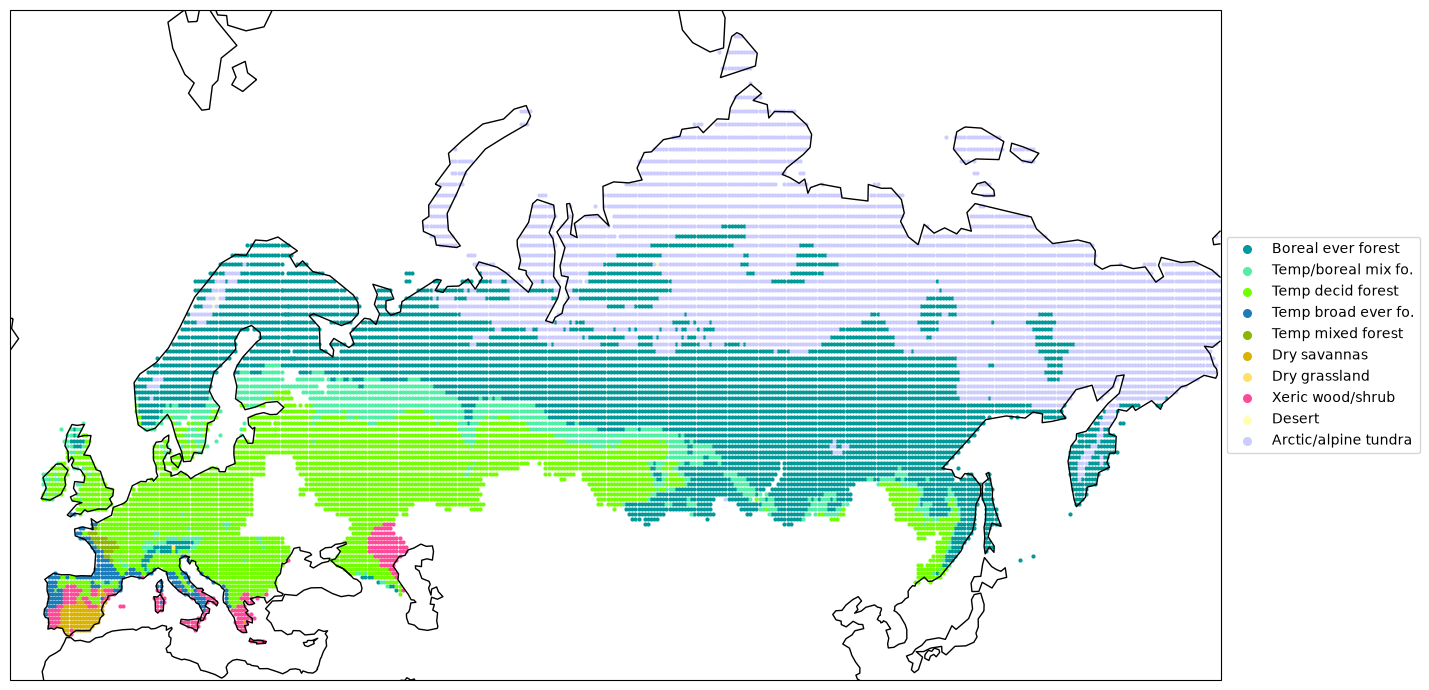

In [128]:
# Predicted biomes in Europe and Russia - a bit problematic because of how the model is trained. Probably not good to use in report

# Predictions
X_europe = europe_df.select(X_red_std.columns).to_pandas()
oof_pred = cross_val_predict(multi_class3, X_europe, y, cv=cv, n_jobs=-1)
russia_pred = multi_class3.predict(russia_df.select(X_red_std.columns).to_pandas())

# Add predictions to dataframes
europe_pred_df = europe_df.with_columns(pl.Series("Biome_pred", oof_pred))
russia_pred_df = russia_df.with_columns(pl.Series("Biome_pred", russia_pred))
present_biomes = sorted(set(oof_pred.tolist()) | set(russia_pred.tolist()))

# One map axis
proj = ccrs.Mercator(central_longitude=90)
fig, ax = plt.subplots(figsize=(18, 7), subplot_kw={"projection": proj})
ax.set_extent([-15, 180, 30, 80], crs=ccrs.PlateCarree())

# Plot Europe and Russia together
for biome_id in present_biomes:
    i = int(biome_id) - 1
    name = biome_names[i]
    for df in [europe_pred_df, russia_pred_df]:
        biome = df.filter(pl.col("Biome_pred") == biome_id)
        if biome.height > 0:
            ax.scatter(biome["Lon"].to_numpy(), biome["Lat"].to_numpy(),
                       color=biome_rgbs[i], s=4, label=name if df is europe_pred_df else None,
                       transform=ccrs.PlateCarree())

ax.coastlines()

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
legend = ax.legend(by_label.values(), by_label.keys(), loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
for handle in legend.legend_handles:
    handle.set_sizes([30])

plt.tight_layout()
plt.show()

### Correct and incorrect predictions in Russia

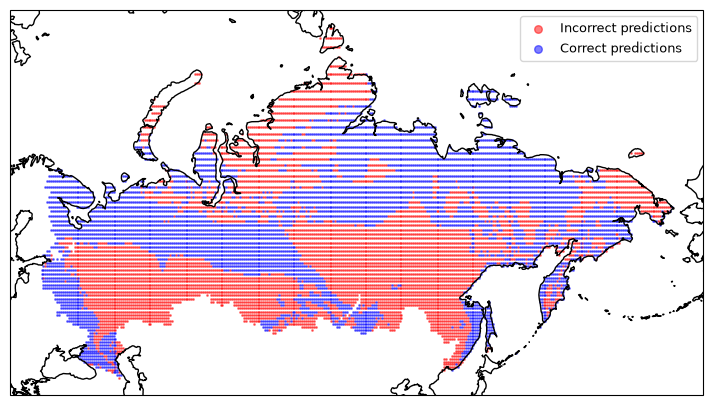

In [67]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": proj_russia})

# Predictions from the new model (without Median, soil, and Std features)
X_russia_model = russia_df.select(X_red_std.columns).to_pandas()
y_rus_pred = multi_class3.predict(X_russia_model)

# Correct and incorrect predictions
correct = y_rus_pred == y_russia
incorrect = y_rus_pred != y_russia

# Filter the Russia dataframe
correct_df = russia_df.filter(pl.Series(correct))
incorrect_df = russia_df.filter(pl.Series(incorrect))

# Plot incorrect predictions
ax.scatter(incorrect_df["Lon"].to_numpy(), incorrect_df["Lat"].to_numpy(),
           color="red", s=1, alpha=0.5, transform=ccrs.PlateCarree(),
           label="Incorrect predictions")

# Plot correct predictions
ax.scatter(correct_df["Lon"].to_numpy(), correct_df["Lat"].to_numpy(),
           color="blue", s=1, alpha=0.5, transform=ccrs.PlateCarree(),
           label="Correct predictions")

ax.coastlines()
legend = ax.legend(fontsize=9)
for handle in legend.legend_handles:
    handle.set_sizes([30])

# plt.title("Correct and Incorrect Predictions in Russia")
plt.show()

## SHAP values 

In [72]:
# SHAP analysis for the new multi-class model
sample = X_red_std.sample(n=min(500, len(X_red_std)), seed=RANDOM_STATE).to_pandas()
explainer = shap.TreeExplainer(multi_class3)
sv = explainer.shap_values(sample)
sv = np.stack(sv, axis=-1) if isinstance(sv, list) else sv

### Mean SHAP (feature importance for all biomes)

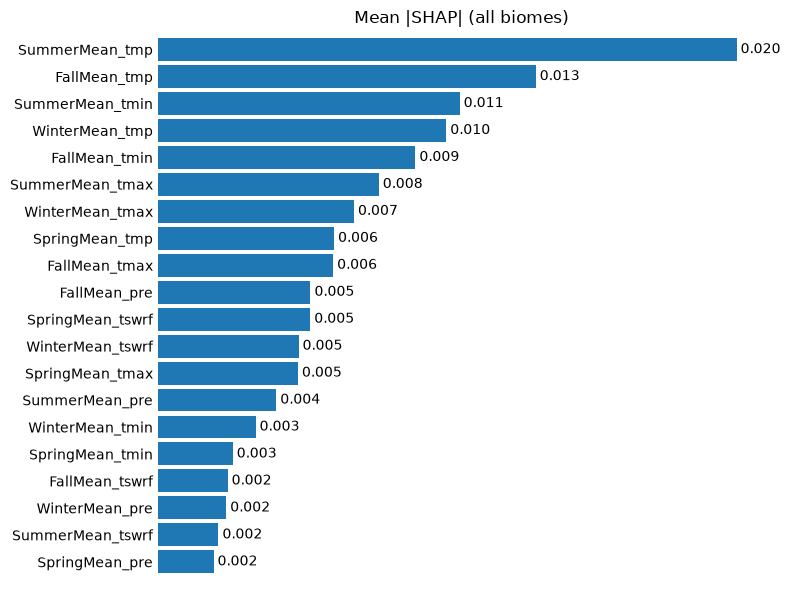

In [76]:
# Global feature importance: mean |SHAP| across all biomes
importance = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=sample.columns).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot.barh(ax=ax, width=0.85)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Mean |SHAP| (all biomes)")
ax.set_xticks([])
ax.tick_params(axis="y", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

for i, value in enumerate(importance):
    ax.text(value, i, f" {value:.3f}", va="center")

plt.tight_layout()
plt.show()


### Plots for individual biomes

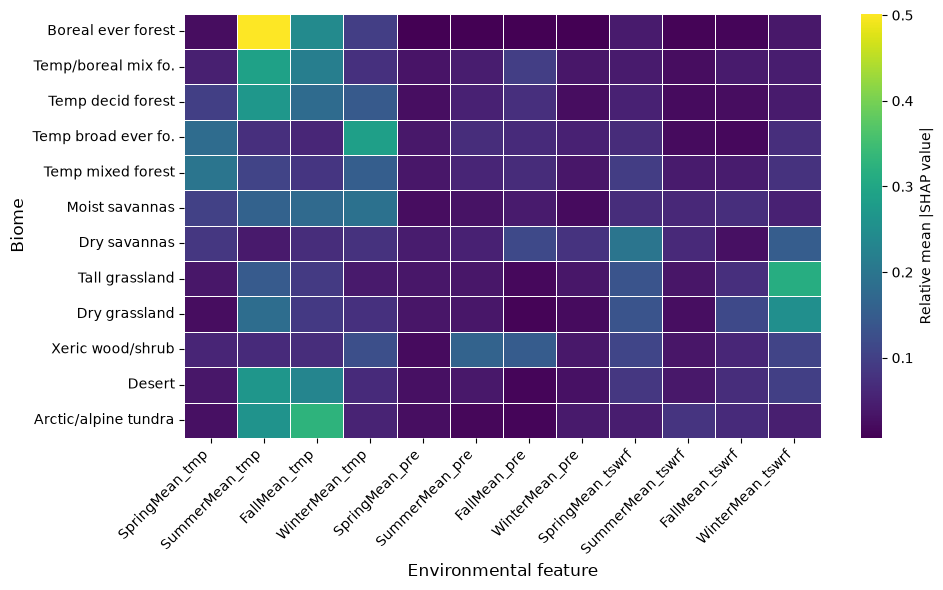

In [77]:
# Plot the realtive importance of the features for each biome in a heatmap
# Mean absolute SHAP value for each feature and biome
mean_abs_shap = np.abs(sv).mean(axis=0)

# Convert to DataFrame:
# rows = biomes
# columns = features
importance_df = pd.DataFrame(mean_abs_shap.T, index=multi_class3.classes_, columns=sample.columns)

selected_features = ["SpringMean_tmp",  "SummerMean_tmp", "FallMean_tmp", "WinterMean_tmp",
                      "SpringMean_pre", "SummerMean_pre", "FallMean_pre",  "WinterMean_pre",
                      "SpringMean_tswrf", "SummerMean_tswrf", "FallMean_tswrf","WinterMean_tswrf"]

# Give the rows the biome names
importance_df.index = [biome_names[i - 1] for i in multi_class3.classes_]
importance_selected = importance_df[selected_features]  
importance_relative = importance_selected.div(importance_selected.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(importance_relative, cmap="viridis", linewidths=0.5, cbar_kws={"label": "Relative mean |SHAP value|"})
plt.xlabel("Environmental feature", fontsize=12)
plt.ylabel("Biome", fontsize=12)
#plt.title("Relative feature importance for selected climate features (multi-class model, Europe)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#print("observations, features, biomes")
#print(np.array(sv).shape)


High value (yellow) means that the feature contributed stronly to the model's predictions for this biome, relative to the other selected features. 

In [78]:
# most commonly predicted biomes in the test set
pred = multi_class3.predict(X_red_std)
pd.Series(pred).value_counts()

5     1348
2      660
3      274
6      171
15     150
12     102
18      62
7       34
17       8
11       4
14       4
Name: count, dtype: int64

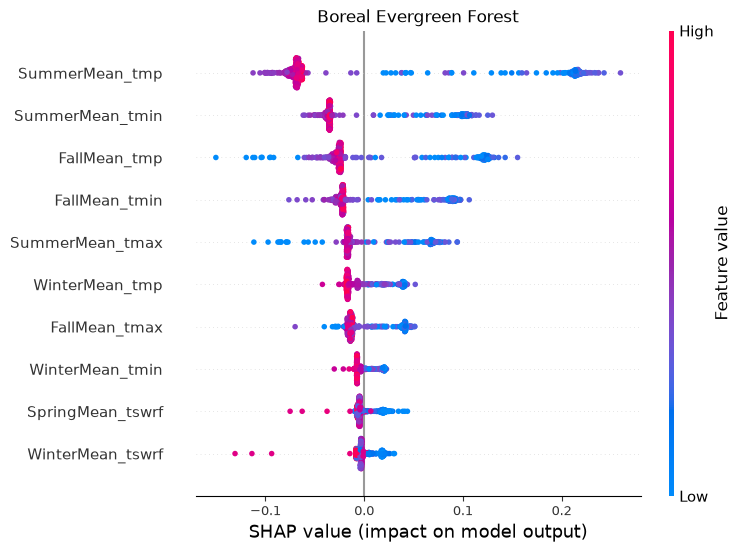

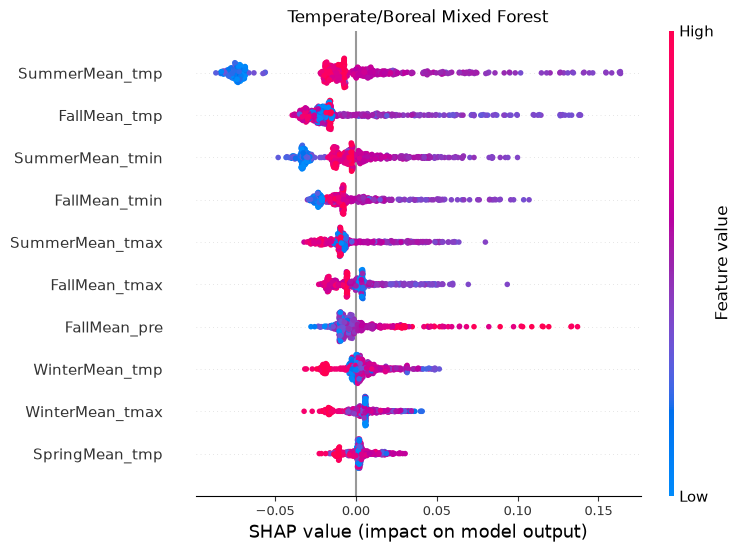

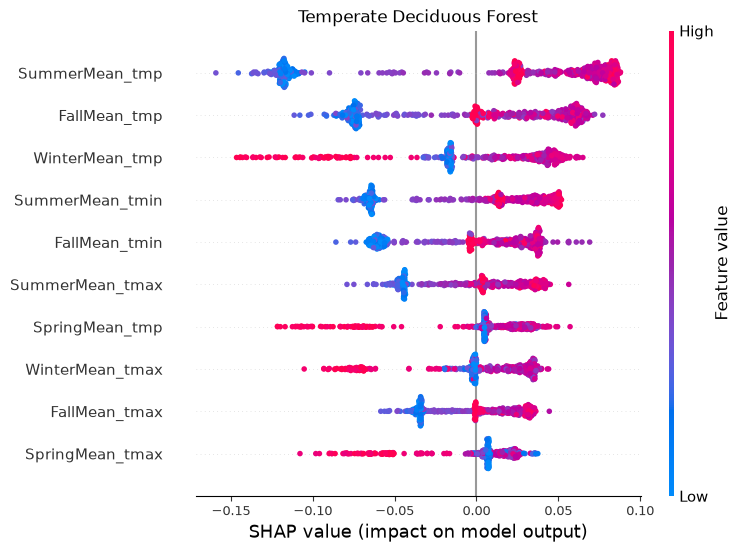

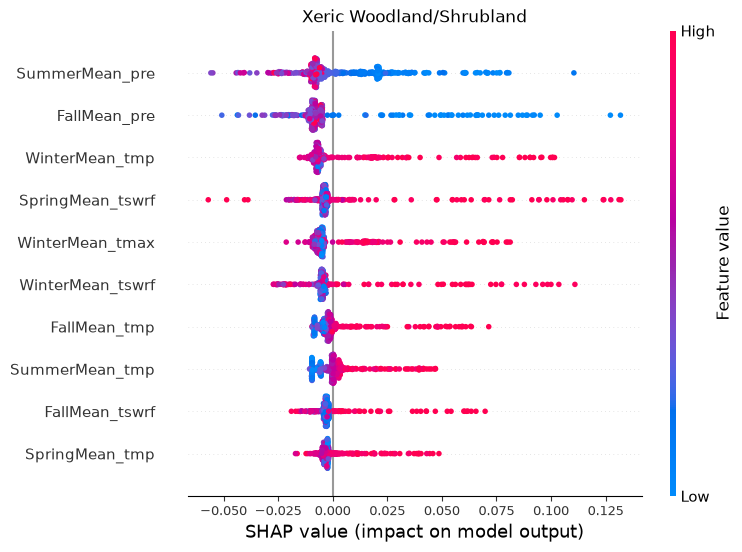

In [79]:
"""for biome in [2, 3, 5, 15]:
    k = list(multi_class3.classes_).index(biome)
    shap.summary_plot(sv[:, :, k], sample, max_display=10, show=False)
    plt.yticks(fontsize=11); plt.xticks(fontsize=9)
    plt.title(biome_names[biome - 1]); plt.show()"""

for biome in [2, 3, 5, 15]:
    k = list(multi_class3.classes_).index(biome)
    shap.summary_plot(sv[:, :, k], sample, max_display=10, show=False)
    plt.yticks(fontsize=11); plt.xticks(fontsize=9)
    plt.title({
        2: "Boreal Evergreen Forest",
        3: "Temperate/Boreal Mixed Forest",
        5: "Temperate Deciduous Forest",
        15: "Xeric Woodland/Shrubland"
    }[biome])
    plt.show()

For a particular feature:
- SHAP = 0 → essentially no contribution to that observation's prediction.
- SHAP > 0 → the feature pushes the model toward that biome.
- SHAP < 0 → the feature pushes the model away from that biome.
- Further from 0 → stronger influence.

## 4.6. Compare LPJ-GUESS model and machine learning model
Compare your trained against the biomes estimated by LPJ-GUESS for “Biome_Cmax”
and Biome_LAI. Discuss the difference in prediction between the LPJ-GUESS outputs and
the machine learning model outputs. Where do the models agree and where do the model
predictions diverge? Why?

In [82]:
obs_russia = russia_df["Biome_obs_lpj"].cast(pl.Int32).to_numpy()
X_russia_model = russia_df.select(X_red_std.columns).to_pandas()
y_pred_rf = multi_class3.predict(X_russia_model)

preds = {
    "RF tuned": y_pred_rf,
    "LPJ Cmax": russia_df["Biome_Cmax_lpj"].cast(pl.Int32).to_numpy(),
    "LPJ Lai": russia_df["Biome_LAI_lpj"].cast(pl.Int32).to_numpy()
}

metrics_comp = []
for name, p in preds.items():
    metrics_comp.append({
        "model": name,
        "accuracy": accuracy_score(obs_russia, p),
        "macro F1": f1_score(obs_russia, p, average="macro", labels=np.unique(obs_russia), zero_division=0),
        "Cohen's kappa": cohen_kappa_score(obs_russia, p)
    })

display(pd.DataFrame(metrics_comp).set_index("model").round(3))

print("Agreement between the tuned multi-class model and LPJ-GUESS predictions:")
print(f"RF vs. Cmax: {(preds['RF tuned'] == preds['LPJ Cmax']).mean():.3f}")
print(f"RF vs. Lai: {(preds['RF tuned'] == preds['LPJ Lai']).mean():.3f}")

,accuracy,macro F1,Cohen's kappa
model,,,
RF tuned,0.470,0.199,0.260
LPJ Cmax,0.094,0.097,0.036
LPJ Lai,0.050,0.080,0.005


Agreement between the tuned multi-class model and LPJ-GUESS predictions:
RF vs. Cmax: 0.071
RF vs. Lai: 0.050


 - RF tuned: our tuned multi class model
 - LPJ Cmax: LJP guess outputs (what this model predicts)
 - LPJ Lai: Leaf area index

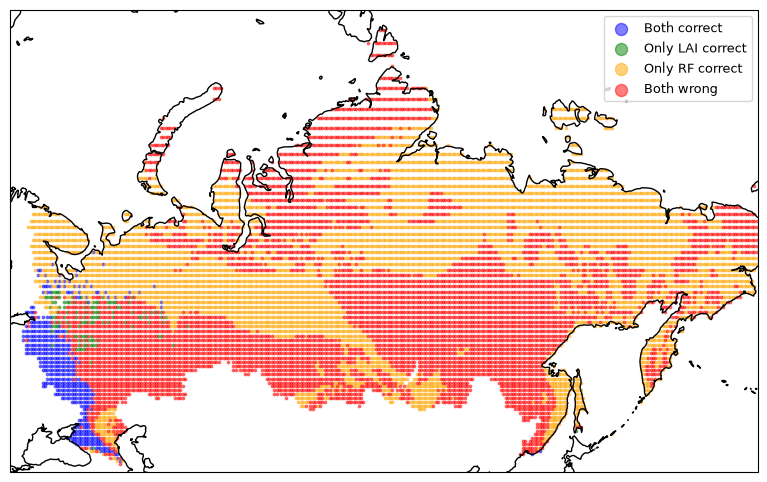

In [122]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.Mercator()})
ax.set_extent([25, 180, 40, 80], crs=ccrs.PlateCarree())

rf_pred = multi_class3.predict(russia_df.select(X_red_std.columns).to_pandas())
lai_pred = preds["LPJ Lai"]
rf_correct = rf_pred == y_russia
lai_correct = lai_pred == y_russia

categories = [
    (rf_correct & lai_correct, "blue", "Both correct"),
    (~rf_correct & lai_correct, "green", "Only LAI correct"),
    (rf_correct & ~lai_correct, "orange", "Only RF correct"),
    (~rf_correct & ~lai_correct, "red", "Both wrong")
]
for mask, color, label in categories:
    df = russia_df.filter(pl.Series(mask))
    ax.scatter(df["Lon"].to_numpy(), df["Lat"].to_numpy(), color=color, s=3, alpha=0.5, transform=ccrs.PlateCarree(), label=label)
ax.coastlines()
ax.legend(fontsize=9, markerscale=5)
plt.show()



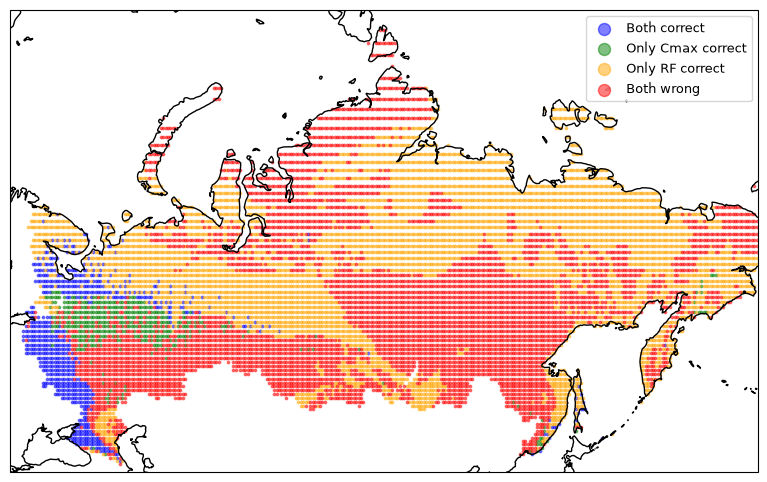

In [123]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.Mercator()})
ax.set_extent([25, 180, 40, 80], crs=ccrs.PlateCarree())

rf_pred = multi_class3.predict(russia_df.select(X_red_std.columns).to_pandas())
cmax_pred = preds["LPJ Cmax"]

rf_correct = rf_pred == y_russia
cmax_correct = cmax_pred == y_russia

categories = [
    (rf_correct & cmax_correct, "blue", "Both correct"),
    (~rf_correct & cmax_correct, "green", "Only Cmax correct"),
    (rf_correct & ~cmax_correct, "orange", "Only RF correct"),
    (~rf_correct & ~cmax_correct, "red", "Both wrong")
]

for mask, color, label in categories:
    df = russia_df.filter(pl.Series(mask))
    ax.scatter(df["Lon"].to_numpy(), df["Lat"].to_numpy(), color=color, s=3, alpha=0.5, transform=ccrs.PlateCarree(), label=label)

ax.coastlines()
ax.legend(fontsize=9, markerscale=5)
plt.show()